### Package management

In [87]:
pip install numpy matplotlib pandas pymc arviz pytensor

### Imports

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt

### Survey Data Setup

In [89]:
from dataframe_gymnastics import (
    map_institution,
    year_2019,
    year_2026,
    load_2019_data_students,
    load_2019_data_educators,
    load_2019_data_admintech,
    load_2026_data_students,
    load_2026_data_educators, 
    load_2026_data_admintech,
    merge_2019_with_2026
)

In [90]:

df_2019_students = load_2019_data_students()
df_2019_educators = load_2019_data_educators()
df_2019_admintech = load_2019_data_admintech()
df_2026_students = load_2026_data_students()
df_2026_educators = load_2026_data_educators()
df_2026_admintech = load_2026_data_admintech()

# define the special cases of mismatch between questions we can analyse, but have slightly different names
# key: 2019 question, value: 2026 question
# in merge: rewrite the 2019 question to match the 2026 question, so that we can merge the dataframes

# question "key" should be renamed to "value" in 2019, to match 2026
special_cases_good_questions = {''
    "educators": {
        "Students.3": "Students.2",     # <- mismatch in numbering
        # "Informal feedback from students": "Informal feed-back from students"
        "Collaborative skills.3": "Collaborative skills",
    },
    "students": {},
    "admintech": {}
}
(
    df_students, 
    df_educators, 
    df_admintech, 
    # common_questions_students, 
    # common_questions_educators, 
    # common_questions_admintech
) = merge_2019_with_2026(
        df_2019_students, 
        df_2019_educators, 
        df_2019_admintech, 
        df_2026_students, 
        df_2026_educators, 
        df_2026_admintech,
        special_cases_good_questions
    )

c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\dataframe_gymnastics.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2019_students["year"] = year_2019
c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\dataframe_gymnastics.py:93: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["institution"] = df["Which of these educational institutions are you studying at?"].replace(
c:\Users\NoahH\OneDrive - UiT Office

handling special cases dict_keys([])
handling special cases dict_keys(['Students.3', 'Collaborative skills.3'])
column Students.2 now contain resposes previously known as Students.3 in 2019 educators dataframe
column Collaborative skills now contain resposes previously known as Collaborative skills.3 in 2019 educators dataframe
handling special cases dict_keys([])


c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\dataframe_gymnastics.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2019_educators[value] = df_2019_educators[key]
c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\dataframe_gymnastics.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2019_educators[value] = df_2019_educators[key]
c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tr

### Find the viable questions

In [91]:
# questions
from axes import detect_axis 
from axes_container import map_typos

special_cases_bad_questions = {
    "educators": [
        "Research on your own teaching (e.g. scholarship of teaching and learning projects)",   # <- only 5 step likert scale, mismatch with model.
        "Education sessions at conferences",                                                    # <- only 5 step likert scale, mismatch with model.                                                                                                             
        "Education seminars",                                                                   # <- only 5 step likert scale, mismatch with model.             
        "Teaching development courses",                                                         # <- only 5 step likert scale, mismatch with model.                     
        "Other courses related to teaching or development of teaching",                          # <- only 5 step likert scale, mismatch with model.              
        # "Other courses related to teaching or development of teaching,"
        # "Looking at/experiencing key field sites",
        # "Having group discussions",
        # "Listening to field lectures",
        # "Data collection/sampling",
        # "Interpret results",
        # "Formulating/testing hypotheses"             
        # "Students.2",  # <- does not match     incorrect -> is now renamed to in 2019 to match 2026
        "Collaborative skills.1" # refer to two different questions!
],
    "students": [
        "Collaborative skills",                                             # <- refer to two different questions
        "Collaborative skills.1",                                           # <- refer to two different questions
        "National courses (GeoPraksis/RealfagsPraksis, Geofare Kurs)",      # <- only 5 step likert scale, mismatch with model.                                                                
        "GeoLearning conferences"                                           # <- only 5 step likert scale, mismatch with model.                            
        "GeOrakel student activity",                                        # <- only 5 step likert scale, mismatch with model.                                
        "Career day",                                                       # <- only 5 step likert scale, mismatch with model.                
        "Student assistant in courses"                                      # <- only 5 step likert scale, mismatch with model.       
        "Observing key field sites",              # 5 scale              
        "Having group discussions",               # 5 scale          
        "Listening to field lectures",            # 5 scale              
        "Data collection/sampling",               # 5 scale          
        "Interpret results",                      # 5 scale      
        "Formulating and testing hypotheses.1",   # 5 scale                          # formulated the as a different question
        "Documentation (field notes)",             # 5 scale       
        "Fieldwork skills",                           # <- asked differently 18/19 to 26      
        "Laboratory skills",                          # <- asked differently 18/19 to 26          
        "Modelling/computing skills",                 # <- asked differently 18/19 to 26                  
        "Theoretical understanding",                  # <- asked differently 18/19 to 26                  
        "Communicating scientific/technical content", # <- asked differently 18/19 to 26                                                                 
], 
    "admintech": [
        "Research on your own teaching (e.g. scholarship of teaching and learning projects)",   # <- only 5 step likert scale, mismatch with model.
        "Education sessions at conferences",                                                    # <- only 5 step likert scale, mismatch with model.                                                                                                             
        "Education seminars",                                                                   # <- only 5 step likert scale, mismatch with model.             
        "Teaching development courses",                                                         # <- only 5 step likert scale, mismatch with model.                     
        "Other courses related to teaching or development of teaching",                          # <- only 5 step likert scale, mismatch with model.              
        # "Looking at/experiencing key field sites",
        "Collaborative skills.1",                                           # <- refer to two different questions (obtained skills versus internship effect)
    ]
}


def get_scale(question, dataframe):
    """get a prototype ofthe scale of a question in a dataframe"""
    return dataframe[question].dropna().unique()

def clean_scale_entries(scale_entries):
    """keep only the entries that can be converted to numbers, and sort them"""
    return sorted([entry for entry in scale_entries if entry[0].isdigit()])
    
def isambiguous_scale(scale_entries):
    """
    check if multiple instances of 1 and 7 have different text
    """
    for entry in scale_entries:
        if entry[0] == "7":
            for other_entry in scale_entries:
                if other_entry.strip() == entry.strip():
                    continue
                if other_entry[0] == "7":
                    print(f"Ambiguous scale detected: {entry} and {other_entry}, {entry == other_entry}")
                    return True
                
        elif entry[0] == "1":
            for other_entry in scale_entries:
                if other_entry.strip() == entry.strip():
                    continue
                if other_entry[0] == "1":
                    print(f"Ambiguous scale detected: {entry} and {other_entry}, {entry == other_entry}")
                    return True
                

    return False

def find_viable_questions(dataframe, selection):
    """find the questions we can analyse from one of the dataframes"""

    # some questions are special cases, and we want to ignore them
    ignore = ["year", "institution"] + special_cases_bad_questions[selection]

    # loop thorugh questions in dataframe and get the scale 
    viable_questions_scale_exist = {}
    for question in dataframe.columns:

        if question in ignore:
            print(f"Ignoring question: {question}")
            continue


        # check using the detect_axis function if the question has a scale
        scale = detect_axis(dataframe[question])
        
        if scale is None:
            print(f"No scale detected for question: {question}")
            continue

        # find the unique entries in the scale and clean them
        scale_entries = get_scale(question, dataframe)
        scale_entries = [str(entry) for entry in scale_entries]  # Ensure all entries are strings
        scale_entries = clean_scale_entries(scale_entries)

        # Apply typo mapping
        scale_entries = [map_typos.get(entry, entry) for entry in scale_entries]

        if isambiguous_scale(scale_entries):
            print((f"Ambiguous scale detected for question: {question}, ^"))
            continue

        if len(scale_entries) == 0:
            continue
    
        # finally check, that the second character is a dot
        for entry in scale_entries:
            if len(entry) > 1 and entry[1] != ".":
                continue

        # if question == "Other courses related to teaching or development of teaching":
        #     print(f"Special case of bad question: {question}") 
        #     continue

        viable_questions_scale_exist[question] = scale_entries

    return viable_questions_scale_exist


In [92]:
print("Finding viable questions for educators...")
viable_questions_educators = find_viable_questions(df_educators, "educators")
print("\nFinding viable questions for students...")   
viable_questions_students = find_viable_questions(df_students, "students")
print("\nFinding viable questions for admintech...")   
viable_questions_admintech = find_viable_questions(df_admintech, "admintech")


Finding viable questions for educators...
No scale detected for question: $submission_id
No scale detected for question: $created
No scale detected for question: I agree to participate
No scale detected for question: Where are you employed?
No scale detected for question: What best describes your employment?
No scale detected for question: How many years of teaching experience do you have?
No scale detected for question: What formal pedagogical qualifications do you have?.No formal pedagogical qualification
No scale detected for question: What formal pedagogical qualifications do you have?.Teacher education
No scale detected for question: What formal pedagogical qualifications do you have?.One-year teacher training (Praktisk-pedagogisk utdanning)
No scale detected for question: What formal pedagogical qualifications do you have?.Basic course in university pedagogy
No scale detected for question: What formal pedagogical qualifications do you have?.Other pedagogical qualification
Ignorin

In [93]:
print()
print("Viable questions in educators dataframe:")
for question, scale_entries in viable_questions_educators.items():
    print(f"{question}")
    # print(f"Scale entries: {scale_entries}")
    # print()

print()
print("Viable questions in students dataframe:")
for question, scale_entries in viable_questions_students.items():
    print(f"{question}")
    # print(f"Scale entries: {scale_entries}")
    # print()

print()
print("Viable questions in admintech dataframe:")
for question, scale_entries in viable_questions_admintech.items():
    print(f"{question}")
    # print(f"Scale entries: {scale_entries}")
    # print()


Viable questions in educators dataframe:
Fieldwork skills
Laboratory skills
Modelling/computing skills
Theoretical understanding
Quantitative competence (ability to interpret data /numeracy)
Communicating scientific/technical content
The teachers’ have excellent academic competences
The collegial collaboration in regard to research is excellent
The collegial collaboration in regard to teaching is excellent
The collegial collaboration between academic staff and technical/administration staff is excellent
The general quality of the study programme is excellent
The geoscience department at UiT
The geoscience department at UNIS
The geoscience department at UiO
The geoscience department at UiB
Other departments (not geoscience) at a university
Other geoscience departments at Norwegian universities
Other geoscience departments at non-Norwegian universities
Research institutions
Academic staff
Students
Administrative/technical staff at the department
The academic content
Instruction and asse

### Finding counts

before running the analysis in pymc, we must copy the dataframe and remove the rows which have bad data. But doing do premptively for all questions will remove all responses

In [94]:
def prepare_dataframe(dataframe, common_questions_dict):
    
    common_questions = list(common_questions_dict.keys())

    # Extract the first digit (\d) from the string. 
    # Existing NaNs stay NaN; text-only answers (like "I don't know") naturally become NaN.
    dataframe_digits = dataframe[common_questions].astype(str).apply(lambda x: x.str.extract(r'(\d)')[0])

    # Convert the extracted digits to numeric
    for column in common_questions:
        dataframe[column] = pd.to_numeric(dataframe_digits[column], errors='coerce')

    # set the integers to the same datatype
    dataframe[common_questions] = dataframe[common_questions].astype('Int64')

    # we do want to drop all rows with NaN values for some specific questions
    questions_to_drop_nan = [
        "year",
        "institution",
    ]
    dataframe = dataframe.dropna(subset=questions_to_drop_nan, how='any')

    # start year at 0
    print(f"{dataframe['year'].value_counts() = }")

    return dataframe

df_educators = prepare_dataframe(df_educators, viable_questions_educators)
df_students = prepare_dataframe(df_students, viable_questions_students)
df_admintech = prepare_dataframe(df_admintech, viable_questions_admintech)


dataframe['year'].value_counts() = year
0    152
1     51
Name: count, dtype: int64
dataframe['year'].value_counts() = year
0    224
1     91
Name: count, dtype: int64
dataframe['year'].value_counts() = year
0    177
1     19
Name: count, dtype: int64


### Sanity check

In [95]:
key = "Fieldwork skills"
print(f"{df_students[key].value_counts()}")
print(f"{df_educators[key].value_counts()}")
print(f"{df_admintech[key].value_counts()}")

key = "institution"
print(f"{df_students[key].value_counts()}")
print(f"{df_educators[key].value_counts()}")
print(f"{df_admintech[key].value_counts()}")

key = "year"
print(f"{df_students[key].value_counts()}")
print(f"{df_educators[key].value_counts()}")
print(f"{df_admintech[key].value_counts()}")


Fieldwork skills
7. Extremely important    106
6.                         94
5.                         70
4. Neutral                 24
4.                          8
3.                          4
I don&#39;t know            2
2.                          2
1. Not important            1
Name: count, dtype: int64
Fieldwork skills
6    65
7    54
5    47
4    32
3     3
2     1
Name: count, dtype: Int64
Fieldwork skills
6    61
7    57
5    47
4    25
3     4
2     2
Name: count, dtype: Int64
institution
0    102
3     94
2     89
1     20
4     10
Name: count, dtype: int64
institution
0    69
2    49
1    36
3    31
4    18
Name: count, dtype: int64
institution
0    81
2    47
3    44
1    19
4     5
Name: count, dtype: int64
year
0    224
1     91
Name: count, dtype: int64
year
0    152
1     51
Name: count, dtype: int64
year
0    177
1     19
Name: count, dtype: int64


### Building the ordinal regression model

In [96]:


K = 7 # number of choices on likert scale
num_groups = 5 # number of groups

def make_model(question, dataframe, quiet=False):

    with pm.Model() as model:

        # cutpoints
        cutpoints_init = np.linspace(-2, 2, K - 1) # <- initial guess: latent variable is centered around 0
        cutpoints = pm.Normal(
            "cutpoints",
            mu=cutpoints_init,
            sigma=3, # <- wide prior
            transform=pm.distributions.transforms.ordered,  # Guarantees cutpoint[i] < cutpoint[i+1]
            initval=cutpoints_init
        )

        # intercepts
        # no intercept_mu_population
        intercept_sigma_population = pm.HalfNormal(
            "intercept_sigma_population", sigma=1
        )
        # reparameterization trick
        intercept_groups_offset = pm.Normal("intercept_groups_offset", mu=0, sigma=1, size=num_groups)
        intercept_groups = pm.Deterministic("intercept_groups", intercept_groups_offset * intercept_sigma_population)
                                                            #  ^ the population mean is now constrained to 0, and it is up to the cutpoints to "center" the latent variable 
        # slopes
        slope_mu = pm.Normal("slope_mu", mu=0, sigma=1) # should have been named slope_mu_population
        slope_sigma = pm.HalfNormal("slope_sigma", sigma=1) # slope_sigma_population...
        # reparameterization trick
        slope_groups_offset = pm.Normal("slope_groups_offset", mu=0, sigma=1, size=num_groups)
        slope_groups = pm.Deterministic("slope_groups", slope_mu + slope_groups_offset * slope_sigma)

        # combine group intercepts and group slopes to form the predictor
        # predictor = slope * time + intercept                     <- linear regression
        predictor = pm.Deterministic(
            "predictor", slope_groups[dataframe.institution] * dataframe.year + intercept_groups[dataframe.institution]
        )

        # likelihood
        y = pm.OrderedLogistic("y", cutpoints=cutpoints, eta=predictor, observed=dataframe[question].values.astype(np.int64))


        # relics. year is now either 0 or 1. previously they were 0 and 7
        effect_after_7_years_groups = pm.Deterministic(
            "effect_after_7_years_groups", slope_groups
        )
        effect_after_7_years_population = pm.Deterministic(
            "effect_after_7_years_population", slope_mu
        )

        # calculate odds ratios for population and groups
        odds_ratio_population = pm.Deterministic(
            "odds_ratio_population", pm.math.exp(slope_mu)
        )
        odds_ratio_groups = pm.Deterministic(
            "odds_ratio_groups", pm.math.exp(slope_groups)
        )
        
        idata = pm.sample(
            nuts_sampler="numpyro",
            draws=2000,
            tune=2000,
            target_accept=0.995,
            quiet=quiet,)
        
       
    return idata, model


def analyze(question, dataframe, quiet=False):
    # get counts
    dataframe = dataframe.dropna(subset=[question], how='any').copy()

    # shift questions responses to be 0 indexed
    # 1-7 -> 0-6 

    #     C:\Users\NoahH\AppData\Local\Temp\ipykernel_16632\2763623900.py:74: SettingWithCopyWarning: 
    # A value is trying to be set on a copy of a slice from a DataFrame.
    # Try using .loc[row_indexer,col_indexer] = value instead
    dataframe.loc[:, question] = dataframe.loc[:, question].astype(int) - 1

    # run mcmc
    idata, model = make_model(question, dataframe, quiet=quiet)
    divergent_count = idata.sample_stats.diverging.sum().item()


    return idata, model, divergent_count
    # az.summary(idata, var_names=["slope_mu", "slope_sigma", "intercept_mu_population", "intercept_sigma_population", "effect_after_7_years_population"])
    # az.plot_trace(idata, var_names=["slope_mu", "slope_sigma", "intercept_mu_population", "intercept_sigma_population", "effect_after_7_years_population"])

### Example run

In [97]:
def example_run():
    example_question = "I feel comfortable as a student here"
    idata, model, num_divergences = analyze(example_question, df_students)

    # model.debug()
    # plot with arviz
    az.plot_trace_dist(idata, var_names=["effect_after_7_years_groups", "effect_after_7_years_population"])
    print(f"{num_divergences = }")
# example_run()

### Simulating data for parameter recovery

To test the model, we simulate data and see if we can recover some parameters



#### Simulation

In [98]:
# simulate a survey with distinct values for each group and year, and then fit the model to see if it can recover the parameters.

def make_data(shift):
    n_samples = 1000
    year = np.random.choice([year_2019, year_2026], size=n_samples)
    institution = np.random.choice([0, 1, 2, 3, 4], size=n_samples)
    
    base_score = 4.0
    
    # Apply shift
    interaction_effect = (
        - shift * ((year == year_2026) & (institution == 0))
        + shift * ((year == year_2026) & (institution == 1))
    )
    
    # Add Standard Logistic Noise, epsilon ~ Logistic(location=0, scale=1.0)
    # noise chosen to match the scale of the logistic distribution used in the OrderedLogistic likelihood
    noise = np.random.logistic(0, 1.0, size=n_samples)
    
    # Continuous latent rating
    latent_rating = base_score + interaction_effect + noise
    
    # map to some choice Ordinal Categories using Thresholds (Cutpoints)
    thresholds = [1.5, 2.5, 3.8, 4.5, 5.5, 6.5]
    
    # np.digitize returns indices from 0 to len(thresholds)
    # Adding 1 converts it to a 1-7 scale rating
    explicit_rating = np.digitize(latent_rating, thresholds) + 1
    
    df = pd.DataFrame({
        "latent_rating": latent_rating,
        "explicit_rating": explicit_rating,
        "year": year,
        "institution": institution
    })
    return df


#### Test run

In [99]:

def make_data_test_run():
    df = make_data(shift=0.25)
    print(df.head())

    # plot the distribution of explicit_rating for each institution and year
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))

    bins = np.arange(-0.5, 9.5, 1)
    ax[0].hist(df[df.year == year_2019][df.institution == 0].explicit_rating, bins=bins, histtype="step", label="2019, uib", color="blue")
    ax[0].hist(df[df.year == year_2019][df.institution == 1].explicit_rating, bins=bins, histtype="step", label="2019, uibgeophys", color="green")
    ax[0].hist(df[df.year == year_2019][df.institution == 2].explicit_rating, bins=bins, histtype="step", label="2019, uio", color="orange")
    ax[0].hist(df[df.year == year_2019][df.institution == 3].explicit_rating, bins=bins, histtype="step", label="2019, uit", color="purple")
    ax[0].hist(df[df.year == year_2019][df.institution == 4].explicit_rating, bins=bins, histtype="step", label="2019, unis", color="red")
    ax[1].hist(df[df.year == year_2026][df.institution == 0].explicit_rating, bins=bins, histtype="step", label="2026, uib", color="blue")
    ax[1].hist(df[df.year == year_2026][df.institution == 1].explicit_rating, bins=bins, histtype="step", label="2026, uibgeophys", color="green")
    ax[1].hist(df[df.year == year_2026][df.institution == 2].explicit_rating, bins=bins, histtype="step", label="2026, uio", color="orange")
    ax[1].hist(df[df.year == year_2026][df.institution == 3].explicit_rating, bins=bins, histtype="step", label="2026, uit", color="purple")
    ax[1].hist(df[df.year == year_2026][df.institution == 4].explicit_rating, bins=bins, histtype="step", label="2026, unis", color="red")

    for a in ax:
        a.set_xticks(np.arange(0, 9, 1))
        a.set_xlabel("explicit_rating")
        a.set_ylabel("count")
        a.legend()

    fig, axs=plt.subplots(2, 1)
    # plot the latent and explicit rating over time for each institution
    for inst in range(5):
        axs[0].scatter(df[df.institution == inst].year, df[df.institution == inst].explicit_rating - 1, label=f"institution {inst}", alpha=0.5)
        axs[0].scatter(df[df.institution == inst].year, df[df.institution == inst].latent_rating - 1, label=f"institution {inst}", alpha=0.5)
    axs[0].set_xlabel("year") 
    axs[0].set_ylabel("rating")
    axs[0].legend()

    fig.tight_layout()

    # run the model on the simulated data
    # df["explicit_rating"] = df["explicit_rating"].astype(int) - 1
    idata, model, num_divergences = analyze("explicit_rating", df, quiet=True)
    az.plot_trace_dist(idata, var_names=["effect_after_7_years_groups", "effect_after_7_years_population"])
    print(f"{num_divergences = }")
    uib_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=0).values.flatten() * 7
    uibgeophys_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=1).values.flatten() * 7
    uio_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=2).values.flatten() * 7
    uit_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=3).values.flatten() * 7
    unis_beta_time_posterior = idata.posterior["slope_groups"].sel(slope_groups_dim_0=4).values.flatten() * 7
    population_beta_time_posterior = idata.posterior["slope_mu"].values.flatten() * 7

    uib_beta_time_posterior_counts = np.histogram(uib_beta_time_posterior, bins=100, density=True)
    uibgeophys_beta_time_posterior_counts = np.histogram(uibgeophys_beta_time_posterior, bins=100, density=True)
    uio_beta_time_posterior_counts = np.histogram(uio_beta_time_posterior, bins=100, density=True)
    uit_beta_time_posterior_counts = np.histogram(uit_beta_time_posterior, bins=100, density=True)
    unis_beta_time_posterior_counts = np.histogram(unis_beta_time_posterior, bins=100, density=True)
    population_beta_time_posterior_counts = np.histogram(population_beta_time_posterior, bins=100, density=True)


    print(f"{uib_beta_time_posterior_counts[0].shape = }")
    print(f"{uib_beta_time_posterior_counts[1].shape = }")
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(uib_beta_time_posterior_counts[1][:-1], uib_beta_time_posterior_counts[0], label="UiB")
    ax[0].plot(uibgeophys_beta_time_posterior_counts[1][:-1], uibgeophys_beta_time_posterior_counts[0], label="UiB Geophysics")
    ax[0].plot(uio_beta_time_posterior_counts[1][:-1], uio_beta_time_posterior_counts[0], label="UiO")
    ax[0].plot(uit_beta_time_posterior_counts[1][:-1], uit_beta_time_posterior_counts[0], label="UiT")
    ax[0].plot(unis_beta_time_posterior_counts[1][:-1], unis_beta_time_posterior_counts[0], label="UNIS")
    ax[1].plot(population_beta_time_posterior_counts[1][:-1], population_beta_time_posterior_counts[0], label="Population")
    ax[0].legend()
    for a in ax: a.tick_params(axis='both', which='both', bottom=True, top=True, labelbottom=True)
    # ax[0].hist(uib_beta_time_posterior, bins=30, density=True, histtype='step', label="UiB")
    # ax[0].hist(uibgeophys_beta_time_posterior, bins=30, density=True, histtype='step', label="UiB Geophysics")
    # ax[0].hist(uio_beta_time_posterior, bins=30, density=True, histtype='step', label="UiO")
    # ax[0].hist(uit_beta_time_posterior, bins=30, density=True, histtype='step', label="UiT")
    # ax[0].hist(unis_beta_time_posterior, bins=30, density=True, histtype='step', label="UNIS")
    # ax[1].hist(population_beta_time_posterior, bins=30, density=True, histtype='step', label="Population")
    # ax[0].legend()

    for i in range(5):
        print(f"Group {i} effect after 7 years: mean = {np.mean(idata.posterior['effect_after_7_years_groups'].sel(effect_after_7_years_groups_dim_0=i).values.flatten()):.3f}, std = {np.std(idata.posterior['effect_after_7_years_groups'].sel(effect_after_7_years_groups_dim_0=i).values.flatten()):.3f}")
    print(f"Population effect after 7 years: mean = {np.mean(idata.posterior['effect_after_7_years_population'].values.flatten()):.3f}, std = {np.std(idata.posterior['effect_after_7_years_population'].values.flatten()):.3f}")
    print(f"{idata.posterior["cutpoints"].shape = }")
    fig, ax=plt.subplots()
    bins = np.arange(-10.0, 10.0, 0.1)
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=0).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 1")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=1).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 2")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=2).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 3")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=3).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 4")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=4).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 5")
    ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=5).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 6")
    # ax.hist(idata.posterior["cutpoints"].sel(cutpoints_dim_0=6).values.flatten(), bins=bins, density=True, histtype='step', label="cutpoint 6")
    ax.legend()

    for i in range(6):
        print(f"cutpoint {i+1} mean: {idata.posterior['cutpoints'].sel(cutpoints_dim_0=i).values.flatten().mean()}")

# make_data_test_run()

#### Parameter recovery

In [100]:
def parameter_recovery():
    effects = {}
    shifts = np.linspace(0, 1, 50)
    divergences = []
    for shift in shifts:
        
        df = make_data(shift=shift)
        print(f"{shift = }")
        idata, model, num_divergences = analyze("explicit_rating", df, quiet=True)
        print(f"{num_divergences = }")
        divergences.append(num_divergences)
        # get the effects after 7 years for each group and the population
        effects[shift] = {
            "uib": idata.posterior['effect_after_7_years_groups'].sel(effect_after_7_years_groups_dim_0=0).values.flatten(),
            "uibgeophys": idata.posterior['effect_after_7_years_groups'].sel(effect_after_7_years_groups_dim_0=1).values.flatten(),
            "uio": idata.posterior['effect_after_7_years_groups'].sel(effect_after_7_years_groups_dim_0=2).values.flatten(),
            "uit": idata.posterior['effect_after_7_years_groups'].sel(effect_after_7_years_groups_dim_0=3).values.flatten(),
            "unis": idata.posterior['effect_after_7_years_groups'].sel(effect_after_7_years_groups_dim_0=4).values.flatten(),
            "population": idata.posterior['effect_after_7_years_population'].values.flatten()
        }

        # print(f"Shift: {shift:.2f}, Population effect after 7 years: mean = {np.mean(idata.posterior['effect_after_7_years_population'].values.flatten()):.3f}, std = {np.std(idata.posterior['effect_after_7_years_population'].values.flatten()):.3f}")

    print(f"{divergences = }")
    print(f"{sum(divergences) = }")

    return effects, shifts, divergences, 

# effects, shifts, divergences = parameter_recovery()

In [101]:
def parameter_recovery_credible_intervals(effects, shifts):
    # calculate 95 percent credible intervals for each group and the population
    credible_intervals = {}
    for group in ["uib", "uibgeophys", "uio", "uit", "unis", "population"]:
        credible_intervals[group] = {
            "lower": {},
            "upper": {}
        }
        for shift in shifts:
            lower, upper = np.percentile(effects[shift][group], [2.5, 97.5])
            credible_intervals[group]["lower"][shift] = lower
            credible_intervals[group]["upper"][shift] = upper
    return credible_intervals
# credible_intervals = parameter_recovery_credible_intervals(effects, shifts)

In [102]:
def parameter_recovery_plot(effects, shifts):
    # checking whether the model can recover the true effect after 7 years for each group and the population
    fig, ax=plt.subplots()#(2, 1, figsize=(10, 6), sharex=True)
    for shift in shifts:
        
        ax.errorbar(shift, np.mean(effects[shift]["uib"]), yerr=np.std(effects[shift]["uib"]), fmt='o', color="tab:blue")
        ax.errorbar(shift, np.mean(effects[shift]["uibgeophys"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="tab:orange")
        ax.errorbar(shift, np.mean(effects[shift]["uio"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="k")
        ax.errorbar(shift, np.mean(effects[shift]["uit"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="k")
        ax.errorbar(shift, np.mean(effects[shift]["unis"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="k")
        ax.errorbar(shift, np.mean(effects[shift]["population"]), yerr=np.std(effects[shift]["uibgeophys"]), fmt='o', color="k")
    # ax[0].set_ylabel("Effect after 7 years")

    ax.plot(shifts, -shifts, '--', label="True effect", color="tab:blue")  # line showing the true effect
    ax.plot(shifts, shifts, '--', label="True effect", color="tab:orange")  # line showing the true effect
    # 
    ax.set_xlabel("True effect after 7 years")
    ax.set_ylabel("Estimated effect after 7 years")
    ax.set_title("Model recovery test")
    ax.legend()

# parameter_recovery_plot(effects, shifts)

In [103]:
def parameter_recovery_plot_credible_intervals(credible_intervals, shifts):
    # plot the credible intervals for each group and the population
    fig, ax=plt.subplots()
    ax.plot([shifts, shifts], [[credible_intervals["uib"]["lower"][shift] for shift in shifts], [credible_intervals["uib"]["upper"][shift] for shift in shifts]], color="tab:blue")
    ax.plot([shifts, shifts], [[credible_intervals["uibgeophys"]["lower"][shift] for shift in shifts], [credible_intervals["uibgeophys"]["upper"][shift] for shift in shifts]], color="tab:orange")
    ax.plot([shifts, shifts], [[credible_intervals["uio"]["lower"][shift] for shift in shifts], [credible_intervals["uio"]["upper"][shift] for shift in shifts]], '--', color="k")
    ax.plot([shifts, shifts], [[credible_intervals["uit"]["lower"][shift] for shift in shifts], [credible_intervals["uit"]["upper"][shift] for shift in shifts]], '--', color="k")
    ax.plot([shifts, shifts], [[credible_intervals["unis"]["lower"][shift] for shift in shifts], [credible_intervals["unis"]["upper"][shift] for shift in shifts]], '--', color="k")

    ax.plot(shifts, -shifts, '--', label="True effect", color="tab:blue")  # line showing the true effect
    ax.plot(shifts, shifts, '--', label="True effect", color="tab:orange")  # line showing the true effect
    # 
    ax.set_xlabel("True effect after 7 years")
    ax.set_ylabel("Estimated effect after 7 years")
    ax.set_title("Model recovery test, credible intervals")
    ax.legend()
# parameter_recovery_plot_credible_intervals(credible_intervals, shifts)

### Running model on BaseGeo Data

#### Run

In [104]:
import os

from plots import sanitize_key
def save_diagnostics(diagnostics, filename):
    # convert results to a dataframe and save to csv
    results_df = pd.DataFrame.from_dict(diagnostics, orient='index')
    results_df.to_csv(filename)

def load_diagnostics(filename):
    # load results from csv and convert to a dictionary
    diagnostics_df = pd.read_csv(filename, index_col=0)
    diagnostics = diagnostics_df.to_dict(orient='index')
    return diagnostics

def run_analysis_on_all_questions(dataframe, viable_questions, selection):
    diagnostics = {}
    i = 0
    num_questions = len(viable_questions.keys())
    for question in viable_questions.keys():
        i += 1
        # check if the diagnostics for this question already exist
        diagnostics_filename = f"..\\diagnostics\\" + f"{selection}\\" + f"{sanitize_key(question)[:50]}.nc"
        if os.path.exists(diagnostics_filename):
            print(f"Diagnostics for question {question} already exist, skipping...")
            continue
        
        print(f"Running analysis on question: {question} ({i}/{num_questions})")
        # continue
        idata, model, num_divergences = analyze(question, dataframe, quiet=True)
        print(f"{num_divergences = }")
        if num_divergences != 0:
            print(f"Warning: {num_divergences} divergences detected for question {question}.")
            continue

        # save slope parameters for population and groups to numpy files
        np.save(f"..\\results\\" + f"{selection}\\" + f"{sanitize_key(question)[:50]}_slope_mu.npy", idata.posterior["slope_mu"].values.flatten())
        np.save(f"..\\results\\" + f"{selection}\\" + f"{sanitize_key(question)[:50]}_slope_groups.npy", idata.posterior["slope_groups"].values)

        # save odds ratios for population and groups to numpy files 
        np.save(f"..\\results\\" + f"{selection}\\" + f"{sanitize_key(question)[:50]}_odds_ratio_population.npy", idata.posterior["odds_ratio_population"].values.flatten())
        np.save(f"..\\results\\" + f"{selection}\\" + f"{sanitize_key(question)[:50]}_odds_ratio_groups.npy", idata.posterior["odds_ratio_groups"].values)
        # idata.to_netcdf(f"..\\results\\" + f"{type}\\" + f"{sanitize_key(question)[:50]}.nc")
        
        diagnostics[question] = {
            "model": model,
            "num_divergences": num_divergences
        }
        save_diagnostics(diagnostics, f"..\\diagnostics\\" + f"{selection}\\" + f"{sanitize_key(question)[:50]}.nc")
    
        # plot and save arviz plots for population and groups
        trace_plot = az.plot_trace_dist(idata, var_names=["slope_mu", "slope_groups", "odds_ratio_population", "odds_ratio_groups"])
        trace_plot.savefig(f"..\\figures\\ordinal_regression_trace_dist\\{selection}\\{sanitize_key(question)[:50]}_trace_dist.png")

        plt.close()

In [105]:
# test the saving and loading methods
some_dict = {
    "question1": {
        "idata": None,
        "model": None,
        "num_divergences": 0
    }
}
# save_diagnostics(some_dict, f"..\\results\\educators\\test_results.csv")
# loaded_dict = load_diagnostics(f"..\\results\\educators\\test_results.csv")

In [106]:
# run the model on the actual data. Automatically skips if analysis is already performed
run_analysis_on_all_questions(df_educators, viable_questions_educators, "educators")
run_analysis_on_all_questions(df_students, viable_questions_students, "students")
run_analysis_on_all_questions(df_admintech, viable_questions_admintech, "admintech")


Diagnostics for question Fieldwork skills already exist, skipping...
Diagnostics for question Laboratory skills already exist, skipping...
Diagnostics for question Modelling/computing skills already exist, skipping...
Diagnostics for question Theoretical understanding already exist, skipping...
Diagnostics for question Quantitative competence (ability to interpret data /numeracy) already exist, skipping...
Diagnostics for question Communicating scientific/technical content already exist, skipping...
Diagnostics for question The teachers’ have excellent academic competences already exist, skipping...
Diagnostics for question The collegial collaboration in regard to research is excellent already exist, skipping...
Diagnostics for question The collegial collaboration in regard to teaching is excellent already exist, skipping...
Diagnostics for question The collegial collaboration between academic staff and technical/administration staff is excellent already exist, skipping...
Diagnostics 

#### Loading data and finding credible intervals 

In [107]:

def find_credible_intervals_and_median(posterior_distribution):
    """we want 5% on each side, since we are using the interval to 
    determine whether the odds ratio is significantly different from 1.0 (no effect)"""
    ci_lower = np.percentile(posterior_distribution, 2.5)
    ci_upper = np.percentile(posterior_distribution, 97.5)
    median = np.median(posterior_distribution)
    return (ci_lower, ci_upper), median

def load_odds_ratio_and_credible_interval():
    # load all results
    i = 1
    total_length = len(viable_questions_educators.keys()) + len(viable_questions_students.keys()) + len(viable_questions_admintech.keys())
    credible_intervals = {
        "educators": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}},
        "students": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}},
        "admintech": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}}
    }
    odds_ratios = {
        "educators": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}},
        "students": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}},
        "admintech": {"population": {}, "uib": {}, "uibgeophys": {}, "uio": {}, "uit": {}, "unis": {}}
    }
    for question in viable_questions_educators.keys():
        print(f"{i} / {total_length}", end="\r", flush=True)
        odds_ratio_population = np.load(f"..\\results\\educators\\" + f"{sanitize_key(question)[:50]}_odds_ratio_population.npy")
        odds_ratio_groups = np.load(f"..\\results\\educators\\" + f"{sanitize_key(question)[:50]}_odds_ratio_groups.npy")
        odds_ratios["educators"]["population"][question] = odds_ratio_population
        odds_ratios["educators"]["uib"][question] = odds_ratio_groups[:, :, 0]
        odds_ratios["educators"]["uibgeophys"][question] = odds_ratio_groups[:, :, 1]
        odds_ratios["educators"]["uio"][question] = odds_ratio_groups[:, :, 2]
        odds_ratios["educators"]["uit"][question] = odds_ratio_groups[:, :, 3]
        odds_ratios["educators"]["unis"][question] = odds_ratio_groups[:, :, 4]
        credible_intervals["educators"]["population"][question] = find_credible_intervals_and_median(odds_ratio_population)
        credible_intervals["educators"]["uib"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 0])
        credible_intervals["educators"]["uibgeophys"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 1])
        credible_intervals["educators"]["uio"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 2])
        credible_intervals["educators"]["uit"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 3])
        credible_intervals["educators"]["unis"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 4])
        i += 1

    for question in viable_questions_students.keys():
        print(f"{i} / {total_length}", end="\r", flush=True)
        odds_ratio_population = np.load(f"..\\results\\students\\" + f"{sanitize_key(question)[:50]}_odds_ratio_population.npy")
        odds_ratio_groups = np.load(f"..\\results\\students\\" + f"{sanitize_key(question)[:50]}_odds_ratio_groups.npy")
        odds_ratios["students"]["population"][question] = odds_ratio_population
        odds_ratios["students"]["uib"][question] = odds_ratio_groups[:, :, 0]
        odds_ratios["students"]["uibgeophys"][question] = odds_ratio_groups[:, :, 1]
        odds_ratios["students"]["uio"][question] = odds_ratio_groups[:, :, 2]
        odds_ratios["students"]["uit"][question] = odds_ratio_groups[:, :, 3]
        odds_ratios["students"]["unis"][question] = odds_ratio_groups[:, :, 4]
        credible_intervals["students"]["population"][question] = find_credible_intervals_and_median(odds_ratio_population)
        credible_intervals["students"]["uib"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 0])
        credible_intervals["students"]["uibgeophys"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 1])
        credible_intervals["students"]["uio"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 2])
        credible_intervals["students"]["uit"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 3])
        credible_intervals["students"]["unis"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 4])
        i += 1

    for question in viable_questions_admintech.keys():
        print(f"{i} / {total_length}", end="\r", flush=True)
        odds_ratio_population = np.load(f"..\\results\\admintech\\" + f"{sanitize_key(question)[:50]}_odds_ratio_population.npy")
        odds_ratio_groups = np.load(f"..\\results\\admintech\\" + f"{sanitize_key(question)[:50]}_odds_ratio_groups.npy")
        odds_ratios["admintech"]["population"][question] = odds_ratio_population
        odds_ratios["admintech"]["uib"][question] = odds_ratio_groups[:, :, 0]
        odds_ratios["admintech"]["uibgeophys"][question] = odds_ratio_groups[:, :, 1]
        odds_ratios["admintech"]["uio"][question] = odds_ratio_groups[:, :, 2]
        odds_ratios["admintech"]["uit"][question] = odds_ratio_groups[:, :, 3]
        odds_ratios["admintech"]["unis"][question] = odds_ratio_groups[:, :, 4]
        credible_intervals["admintech"]["population"][question] = find_credible_intervals_and_median(odds_ratio_population)
        credible_intervals["admintech"]["uib"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 0])
        credible_intervals["admintech"]["uibgeophys"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 1])
        credible_intervals["admintech"]["uio"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 2])
        credible_intervals["admintech"]["uit"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 3])
        credible_intervals["admintech"]["unis"][question] = find_credible_intervals_and_median(odds_ratio_groups[:, :, 4])    
        i += 1

    return odds_ratios, credible_intervals

odds_ratios, credible_intervals = load_odds_ratio_and_credible_interval() # selection: group: question


#### example plot

example_result_groups.shape = (4, 2000, 5)


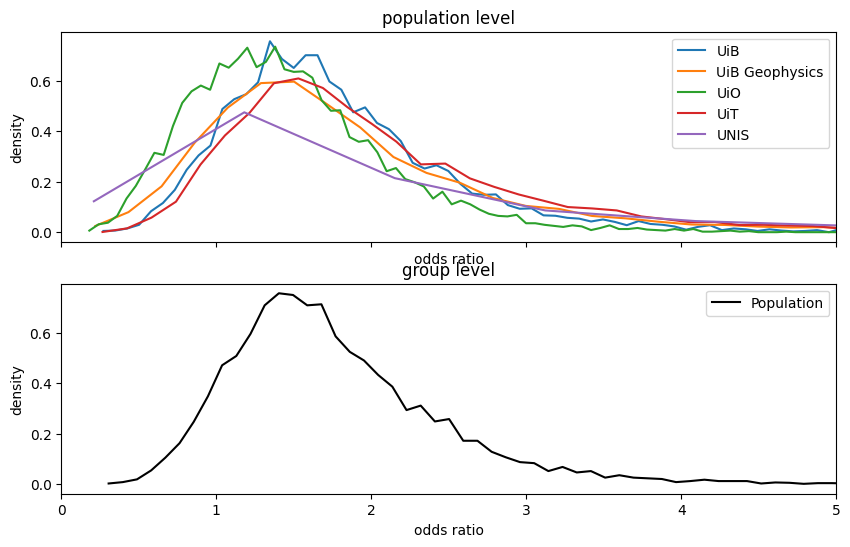

In [108]:
# example_result_population_path = "..\\results\\educators\\The collegial collaboration between academic staff_odds_ratio_population.npy"
# example_result_groups_path = "..\\results\\educators\\The collegial collaboration between academic staff_odds_ratio_groups.npy"
example_result_population_path = "..\\results\\educators\\Fieldwork skills_odds_ratio_population.npy"
example_result_groups_path = "..\\results\\educators\\Fieldwork skills_odds_ratio_groups.npy"
example_result_population = np.load(example_result_population_path)
example_result_groups = np.load(example_result_groups_path)

# find 95% credible intervals for the population and groups
population_ci_lower = np.percentile(example_result_population, 2.5)
population_ci_upper = np.percentile(example_result_population, 97.5)

print(f"{example_result_groups.shape = }")

fig, ax=plt.subplots(2, 1, figsize=(10, 6), sharex=True)

bins = 100
population_odds_ratio_posterior_counts = np.histogram(example_result_population, bins=bins, density=True)
uib_odds_ratio_posterior_counts = np.histogram(example_result_groups[:, :, 0].flatten(), bins=bins, density=True)
uibgeophys_odds_ratio_posterior_counts = np.histogram(example_result_groups[:, :, 1].flatten(), bins=bins, density=True)
uio_odds_ratio_posterior_counts = np.histogram(example_result_groups[:, :, 2].flatten(), bins=bins, density=True)
uit_odds_ratio_posterior_counts = np.histogram(example_result_groups[:, :, 3].flatten(), bins=bins, density=True)
unis_odds_ratio_posterior_counts = np.histogram(example_result_groups[:, :, 4].flatten(), bins=bins, density=True)


colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

ax[0].plot(uib_odds_ratio_posterior_counts[1][:-1], uib_odds_ratio_posterior_counts[0], label="UiB", color=colors[0])
ax[0].plot(uibgeophys_odds_ratio_posterior_counts[1][:-1], uibgeophys_odds_ratio_posterior_counts[0], label="UiB Geophysics", color=colors[1])
ax[0].plot(uio_odds_ratio_posterior_counts[1][:-1], uio_odds_ratio_posterior_counts[0], label="UiO", color=colors[2])
ax[0].plot(uit_odds_ratio_posterior_counts[1][:-1], uit_odds_ratio_posterior_counts[0], label="UiT", color=colors[3])
ax[0].plot(unis_odds_ratio_posterior_counts[1][:-1], unis_odds_ratio_posterior_counts[0], label="UNIS", color=colors[4])

ax[1].plot(population_odds_ratio_posterior_counts[1][:-1], population_odds_ratio_posterior_counts[0], label="Population", color="k")


# for i in range(5):
#     ax[0].hist(example_result_groups[:, :, i].flatten(), bins=bins, density=True, histtype='step', label=f"group {i}", color=colors[i])
#     group_ci_lower = np.percentile(example_result_groups[:, :, i].flatten(), 2.5)
#     group_ci_upper = np.percentile(example_result_groups[:, :, i].flatten(), 97.5)
#     ax[0].axvline(group_ci_lower, linestyle='--', color=colors[i])
#     ax[0].axvline(group_ci_upper, linestyle='--', color=colors[i])


# ax[1].hist(example_result_population, bins=bins, density=True, histtype='step', label="The collegial collaboration between academic staff")
# ax[1].axvline(population_ci_lower, color='k', linestyle='--', label='95% CI lower')
# ax[1].axvline(population_ci_upper, color='k', linestyle='--', label='95% CI upper')

ax[0].set_title("population level")
ax[1].set_title("group level")
for a in ax:
    a.set_xlim(0, 5)
    a.set_xlabel("odds ratio")
    a.set_ylabel("density")
    a.legend()


# fig.suptitle("Odds for choosing a higher category after 7 years\nfor the question: The collegial collaboration between academic staff")

### Visualisation

#### Overview

In [109]:
# load all credible intervals for a type and group and plot them on the same plot
from plots import *
def make_overview_plot(credible_intervals_dictionary, group, subfolder):


    num_questions = len(credible_intervals_dictionary[group])
    # print(f"{credible_intervals_dictionary[group].keys() = }")
    sorted_dict = dict(sorted(credible_intervals_dictionary[group].items(), key=lambda item: item[0][0]))  # sort by the first character of the question key
    fig, ax = plt.subplots(figsize=(12,num_questions//3 + 2))
    for idx, (cred_int, median) in enumerate(sorted_dict.values()):  # sort by the first character of the question key
        ax.plot(cred_int, [idx, idx], marker="|", c="k")
        ax.scatter(median, idx, c="k", marker="o")

    # place reference line
    ax.vlines(1, -1, num_questions, color="k")
    # ax.set_xlim(-0.5, 5)

    ax.set_yticks(range(num_questions), labels=sorted_dict.keys())

    ax.set_xlabel("Odds ratio", fontsize=fig_axis_fs)#\n" + r"$\mathbb{E}[X_{2026}] - \mathbb{E}[X_{18/19}]$", fontsize=fig_axis_fs)
    ax.set_ylabel("Question", fontsize=fig_axis_fs)
    fig.suptitle(f"95% credible intervals\n{subfolder}\n{group}", fontsize=fig_title_fs+2)
    fig.tight_layout()
    fig.savefig(f"..\\figures\\credible_interval_overviews\\{subfolder}\\{group}")
    plt.close()

# for group in credible_intervals["educators"].keys():
#     make_overview_plot(credible_intervals["educators"], group, subfolder="Educators")
# for group in credible_intervals["students"].keys():
#     make_overview_plot(credible_intervals["students"], group, subfolder="Students")
# for group in credible_intervals["admintech"].keys():
#     make_overview_plot(credible_intervals["admintech"], group, subfolder="AdminTech")
    

#### Plot the odds ratios posterior distributions for all questions

In [110]:
# plot all 

def plot_odds_ratio_posteriors(odds_ratios, credible_intervals):

    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    for selection in odds_ratios.keys():
        for question, odds_ratio in odds_ratios[selection][group].items():
            fig, ax = plt.subplots(2, 1, figsize=(12, 6))
            bins = 500

            population_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["population"][question], bins=bins, density=True)
            uib_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["uib"][question].flatten(), bins=bins, density=True)
            uibgeophys_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["uibgeophys"][question].flatten(), bins=bins, density=True)
            uio_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["uio"][question].flatten(), bins=bins, density=True)
            uit_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["uit"][question].flatten(), bins=bins, density=True)
            unis_odds_ratio_posterior_counts = np.histogram(odds_ratios[selection]["unis"][question].flatten(), bins=bins, density=True)


            ax[0].plot(uib_odds_ratio_posterior_counts[1][:-1], uib_odds_ratio_posterior_counts[0], label="UiB", color=colors[0])
            ax[0].plot(uibgeophys_odds_ratio_posterior_counts[1][:-1], uibgeophys_odds_ratio_posterior_counts[0], label="UiB Geophysics", color=colors[1])
            ax[0].plot(uio_odds_ratio_posterior_counts[1][:-1], uio_odds_ratio_posterior_counts[0], label="UiO", color=colors[2])
            ax[0].plot(uit_odds_ratio_posterior_counts[1][:-1], uit_odds_ratio_posterior_counts[0], label="UiT", color=colors[3])
            ax[0].plot(unis_odds_ratio_posterior_counts[1][:-1], unis_odds_ratio_posterior_counts[0], label="UNIS", color=colors[4])
            ax[1].plot(population_odds_ratio_posterior_counts[1][:-1], population_odds_ratio_posterior_counts[0], label="Population", color="k")

            # add lines indicating the 95% credible intervals for each group and the population
            for i, group_name in enumerate(["uib", "uibgeophys", "uio", "uit", "unis"]):
                (group_ci_lower, group_ci_upper), group_median = credible_intervals[selection][group_name][question]
                ax[0].axvline(group_ci_lower, 0.0, 0.25, linestyle='--', color=colors[i])
                ax[0].axvline(group_ci_upper, 0.0, 0.25, linestyle='--', color=colors[i])
                ax[0].scatter(group_median, 0.0, color=colors[i], marker="o")
            
            ax[1].axvline(credible_intervals[selection]["population"][question][0][0], 0.0, 0.25, linestyle='--', color="k")
            ax[1].axvline(credible_intervals[selection]["population"][question][0][1], 0.0, 0.25, linestyle='--', color="k")
            ax[1].scatter(credible_intervals[selection]["population"][question][1], 0.0, color="k", marker="o")
 
            ax[0].set_title("group level")
            ax[1].set_title("population level")
            for a in ax:
                a.set_xlim(0, 5)
                a.set_xlabel("Odds ratio")
                a.set_ylabel("density")
                a.legend()

            # fig.supxlabel(r"$\frac{P(y_i > k)}{P(y_i \leq k)}$", fontsize=fig_axis_fs)
            fig.suptitle(f"Odds for choosing a higher category after 7 years\n{question}", fontsize=fig_title_fs)
            fig.tight_layout()
            fig.savefig(f"..\\figures\\ordinal_regression_raw_odds_ratio_plots\\{selection}\\{sanitize_key(question)[:50]}.png")

            plt.close()

# plot_odds_ratio_posteriors(odds_ratios, credible_intervals)

### Testing the proportional odds assumption

#### constructing unconstrained model

In [111]:
K = 7 # number of choices on likert scale
num_groups = 5 # number of groups

def make_model_unconstrained_sequential(question, dataframe, quiet=False):
    """
    create an unconstrained model for ordinal regression with sequential logit link
    where each split has its own slope, but the intercepts are hierarchical by group
    
    In this model, the intercepts are sort of coupled to the cutpoints (note: we have an intercept for every group around cutpoint 0)
    but not for the rest of the cutpoints
    
    """


    num_cutpoints = K - 1 # 6 splits for a 7-point scale

    with pm.Model() as model:

        # for this model, there is a slope and intercept assigned to every cutpoint

        # ----------------cutpoints----------------
        cutpoint_0 = pm.Normal("cutpoint_0", mu=-2.0, sigma=2) # -2 matches the choice for the constrained model
        cutpoint_deltas = pm.Normal("cutpoint_deltas", mu=0, sigma=1, shape=num_cutpoints - 1)

        # ----------------slopes----------------
        # cutpoint 0
        slope_mu_0 = pm.Normal("slope_mu_0", mu=0, sigma=1)
        slope_sigma_0 = pm.HalfNormal("slope_sigma_0", sigma=1)
        slope_groups_offset_0 = pm.Normal("slope_groups_offset_0", mu=0, sigma=1, shape=num_groups)
        slope_groups_0 = pm.Deterministic("slope_groups_0", slope_mu_0 + slope_groups_offset_0 * slope_sigma_0)
        # cutpoint 1-5
        slope_mu_deltas = pm.Normal("slope_mu_deltas", mu=0, sigma=1, shape=num_cutpoints - 1)
        slope_sigma_deltas = pm.HalfNormal("slope_sigma_deltas", sigma=1)
        slope_groups_offset_deltas = pm.Normal("slope_groups_offset_deltas", mu=0, sigma=1, size=(num_groups, num_cutpoints - 1))
        slope_groups_deltas = pm.Deterministic("slope_groups_deltas", slope_mu_deltas + slope_groups_offset_deltas * slope_sigma_deltas)

        # ----------------intercepts----------------
        # since the first cutpoint is "fixed" at -2, we make the hierarchical model only thorugh shared variance
        # Hierarchical Group Intercepts (Applied to the anchor cutpoint)
        intercept_sigma_groups = pm.HalfNormal("intercept_sigma_groups", sigma=1)
        intercept_groups_offset = pm.Normal("intercept_groups_offset", mu=0, sigma=1, shape=num_groups)
        intercept_groups_0 = pm.Deterministic("intercept_groups_0", cutpoint_0 + intercept_groups_offset * intercept_sigma_groups)

        num_observations = dataframe.shape[0]  # number of observations <- do we actually know?
        num_deltas = num_cutpoints - 1  # 

        # extract the group and year data from the dataframe. Reshape the year indicies into column vectors 
        group_idx = dataframe.institution.values
        year_vec = dataframe.year.values.reshape((num_observations, 1)) # [:, None]  # Shape: (num_observations, 1)



        # ----------------predictor----------------
        # cutpoints
        row_cutpoint_0 = intercept_groups_0[group_idx].reshape((num_observations, 1))  # [:, None]
        
        # row_cutpoint_deltas_exp = pt.ones_like(row_cutpoint_0) * pt.exp(cutpoint_deltas).reshape((1, num_deltas))
        row_cutpoint_deltas = cutpoint_deltas.reshape((1, num_deltas))  # [None, :]  # Broadcasts to (num_observations, 5)
        # all_cutpoints = pt.concatenate([row_cutpoint_0, row_cutpoint_deltas_exp], axis=1)
        # cumulative_cutpoints = pt.cumsum(all_cutpoints, axis=1)  # Shape: (num_observations, 6)

        # slopes
        row_slope_0 = slope_groups_0[group_idx].reshape((num_observations, 1))
        row_slope_deltas = slope_groups_deltas[group_idx]  # Shape: (num_observations, 5)

        all_slopes = pt.concatenate([row_slope_0, row_slope_deltas], axis=1)
        cumulative_slopes = pt.cumsum(all_slopes, axis=1)  # Shape: (num_observations, 6)

        # predictor
        # predictor = cumulative_cutpoints + cumulative_slopes * year_vec  # Shape: (num_observations, 6)


        predictor_0 = row_cutpoint_0 + row_slope_0 * year_vec

        # cutpoint 1-5. All predictor deltas must be strictly positive
        predictor_deltas = pt.exp(row_cutpoint_deltas + row_slope_deltas * year_vec) # we must ensure every delta is postivie. Exp is a nice choice

        # assemble
        predictor_all = pt.concatenate([predictor_0, predictor_deltas], axis=1)

        # summarize the strictly positive predictors
        # predictor_0
        # predictor_0 + predictor_delta_1
        # predictor_0 + predictor_delta_1 + predictor_delta_2
        # ...
        # this is the cumsum function
        predictor = pt.cumsum(predictor_all, axis=1)  # Shape: (num_observations, 6) -> Guaranteed strictly increasing!

        # residuals are described as logistic functions. They have the shape of sigmoids
        # note: as for the constrained model, we also assume residuals that follows a logitic function with parameter s=1
        # Map to Cumulative Logistic Probabilities
        cumulative_probabilities = pm.math.sigmoid(predictor)
        
        # by using the cumulative probabilities, we can find the individual categorial probabilities
        # Slice out individual category probabilities
        p_0 = cumulative_probabilities[:, [0]]
        p_mid = cumulative_probabilities[:, 1:] - cumulative_probabilities[:, :-1]
        p_K = 1.0 - cumulative_probabilities[:, [-1]]
        
        probs = pt.concatenate([p_0, p_mid, p_K], axis=1)

        # Likelihood is formed by treating the data as categories. The ordering is handled trough the cumsum
        y = pm.Categorical("y", p=probs, observed=dataframe[question].values.astype(np.int64))

        # sample
        idata = pm.sample(
            nuts_sampler="numpyro",
            draws=2000,
            tune=2000,
            target_accept=0.99, 
            quiet=quiet
        )
        
    return idata, model



import pymc as pm
import pytensor.tensor as pt
import numpy as np

K = 7  # number of choices on likert scale
num_groups = 5  # number of groups

def make_model_unconstrained_sequential(question, dataframe, quiet=False):
    """
    Create an unconstrained model for ordinal regression with sequential logit link
    where each split has its own linear slope, using a boundary structural prior 
    to prevent lines from crossing and causing divergent transitions.
    """
    num_cutpoints = K - 1  # 6 splits for a 7-point scale
    num_deltas = num_cutpoints - 1  # 5 splits to model as deltas
    
    # Identify the maximum year in your data to set the upper boundary check
    max_year = float(dataframe.year.max())
    if max_year == 0:
        raise ValueError("The maximum value in the year column cannot be 0. Ensure years are coded starting at 0 (e.g., 0, 1).")

    with pm.Model() as model:

        # ----------------- Cutpoints -----------------
        cutpoint_0 = pm.Normal("cutpoint_0", mu=-2.0, sigma=2) 
        cutpoint_deltas = pm.Normal("cutpoint_deltas", mu=0, sigma=1, shape=num_deltas)

        # ----------------- Slopes -----------------
        # Cutpoint 0 (Stays unconstrained)
        slope_mu_0 = pm.Normal("slope_mu_0", mu=0, sigma=1)
        slope_sigma_0 = pm.HalfNormal("slope_sigma_0", sigma=1)
        slope_groups_offset_0 = pm.Normal("slope_groups_offset_0", mu=0, sigma=1, shape=num_groups)
        slope_groups_0 = pm.Deterministic("slope_groups_0", slope_mu_0 + slope_groups_offset_0 * slope_sigma_0)
        
        # Cutpoint 1-5 (Modeled via log-gaps at the maximum year to prevent crossing)
        slope_mu_max_year_log = pm.Normal("slope_mu_max_year_log", mu=0, sigma=1, shape=num_deltas)
        slope_sigma_deltas = pm.HalfNormal("slope_sigma_deltas", sigma=1)
        slope_groups_offset_max_log = pm.Normal("slope_groups_offset_max_log", mu=0, sigma=1, size=(num_groups, num_deltas))
        slope_groups_max_year_log = pm.Deterministic(
            "slope_groups_max_year_log", 
            slope_mu_max_year_log + slope_groups_offset_max_log * slope_sigma_deltas
        )

        # ----------------- Intercepts -----------------
        intercept_sigma_groups = pm.HalfNormal("intercept_sigma_groups", sigma=1)
        intercept_groups_offset = pm.Normal("intercept_groups_offset", mu=0, sigma=1, shape=num_groups)
        intercept_groups_0 = pm.Deterministic("intercept_groups_0", cutpoint_0 + intercept_groups_offset * intercept_sigma_groups)

        # ----------------- Data Handling -----------------
        num_observations = dataframe.shape[0]
        group_idx = dataframe.institution.values
        year_vec = dataframe.year.values.reshape((num_observations, 1)) 

        # ----------------- Predictor Setup -----------------
        # 1. Base Cutpoints (Gaps at Year = 0)
        row_cutpoint_0 = intercept_groups_0[group_idx].reshape((num_observations, 1))  
        row_cutpoint_deltas_year0 = pt.ones_like(row_cutpoint_0) * pt.exp(cutpoint_deltas).reshape((1, num_deltas))
        
        all_cutpoints = pt.concatenate([row_cutpoint_0, row_cutpoint_deltas_year0], axis=1)
        cumulative_cutpoints = pt.cumsum(all_cutpoints, axis=1)  # Shape: (num_observations, 6)

        # 2. Linear Slopes Derived from End-Boundary Gaps
        row_slope_0 = slope_groups_0[group_idx].reshape((num_observations, 1))
        
        # Map back the guaranteed positive gaps at your maximum year boundary
        row_gap_at_max_year = pt.exp(slope_groups_max_year_log)[group_idx]  # Shape: (num_observations, 5)
        
        # Linear slope formula: slope = (Gap_at_End - Gap_at_Start) / Time_Delta
        row_slope_deltas = (row_gap_at_max_year - row_cutpoint_deltas_year0) / max_year
        
        all_slopes = pt.concatenate([row_slope_0, row_slope_deltas], axis=1)
        
        # Track the absolute cumulative slope per group for your deterministic outputs
        # This mirrors what your NumPy script calculates downstream
        pm.Deterministic("cumulative_slopes_by_group", pt.cumsum(pt.concatenate([
            slope_groups_0.reshape((num_groups, 1)), 
            (pt.exp(slope_groups_max_year_log) - pt.exp(cutpoint_deltas).reshape((1, num_deltas))) / max_year
        ], axis=1), axis=1))

        cumulative_slopes = pt.cumsum(all_slopes, axis=1)  # Shape: (num_observations, 6)

        # 3. Final Linear Predictor assembly
        predictor = cumulative_cutpoints + cumulative_slopes * year_vec  # Shape: (num_observations, 6)

        # ----------------- Likelihood -----------------
        cumulative_probabilities = pm.math.sigmoid(predictor)
        
        p_0 = cumulative_probabilities[:, [0]]
        p_mid = cumulative_probabilities[:, 1:] - cumulative_probabilities[:, :-1]
        p_K = 1.0 - cumulative_probabilities[:, [-1]]
        
        probs = pt.concatenate([p_0, p_mid, p_K], axis=1)

        y = pm.Categorical("y", p=probs, observed=dataframe[question].values.astype(np.int64))

        # ----------------- MCMC Sampling -----------------
        idata = pm.sample(
            nuts_sampler="numpyro",
            draws=2000,
            tune=2000,
            target_accept=0.99, 
            quiet=quiet
        )
        
    return idata, model



def analyze_unconstrained_sequential(question, dataframe, quiet=False):
    # get counts
    dataframe = dataframe.dropna(subset=[question], how='any').copy()

    # shift questions responses to be 0 indexed

    #     C:\Users\NoahH\AppData\Local\Temp\ipykernel_16632\2763623900.py:74: SettingWithCopyWarning: 
    # A value is trying to be set on a copy of a slice from a DataFrame.
    # Try using .loc[row_indexer,col_indexer] = value instead
    dataframe.loc[:, question] = dataframe.loc[:, question].astype(int) - 1

    # run mcmc
    idata, model = make_model_unconstrained_sequential(question, dataframe, quiet=quiet)
    divergent_count = idata.sample_stats.diverging.sum().item()


    return idata, model, divergent_count
    # az.summary(idata, var_names=["slope_mu", "slope_sigma", "intercept_mu_population", "intercept_sigma_population", "effect_after_7_years_population"])
    # az.plot_trace(idata, var_names=["slope_mu", "slope_sigma", "intercept_mu_population", "intercept_sigma_population", "effect_after_7_years_population"])


#### defining POA analysis

In [ ]:
def compute_log_likelihood(model, idata):
    # clear initial values
    for rv in model.rvs_to_initial_values:
        model.rvs_to_initial_values[rv] = None

    # compute log-likelihood
    with model:
        pm.compute_log_likelihood(idata)

def compare(idata_constrained, idata_unconstrained, elpd_diff_threshold=4.0):
    CONSTRAINED = "constrained"
    UNCONSTRAINED = "unconstrained"
    comp_dict = {
        CONSTRAINED: idata_constrained,
        UNCONSTRAINED: idata_unconstrained,
    }
    comp_df = az.compare(comp_dict)

    # resolve version-dependent column names once
    elpd_col = "elpd_loo" if "elpd_loo" in comp_df.columns else "elpd"
    p_col = "p_loo" if "p_loo" in comp_df.columns else "p"
    warning_col = "warning" if "warning" in comp_df.columns else None

    if warning_col is None:
        raise KeyError(
            f"No 'warning' column found in az.compare output. "
            f"Available columns: {comp_df.columns.tolist()}. "
            f"Update the compare() function to match your ArviZ version."
        )

    loo_constrained = az.loo(idata_constrained, pointwise=True)
    loo_unconstrained = az.loo(idata_unconstrained, pointwise=True)
    khat_constrained = loo_constrained.pareto_k.values
    khat_unconstrained = loo_unconstrained.pareto_k.values

    result = {
        "comp_df": comp_df,
        "elpd_loo_constrained": comp_df.loc[CONSTRAINED, elpd_col],
        "elpd_loo_unconstrained": comp_df.loc[UNCONSTRAINED, elpd_col],
        "p_loo_constrained": comp_df.loc[CONSTRAINED, p_col],
        "p_loo_unconstrained": comp_df.loc[UNCONSTRAINED, p_col],
        "az_warning_constrained": comp_df.loc[CONSTRAINED, warning_col],
        "az_warning_unconstrained": comp_df.loc[UNCONSTRAINED, warning_col],
        "khat_max_constrained": khat_constrained.max(),
        "khat_max_unconstrained": khat_unconstrained.max(),
        "khat_bad_count_constrained": int((khat_constrained > 0.7).sum()),
        "khat_bad_count_unconstrained": int((khat_unconstrained > 0.7).sum()),
        "khat_borderline_count_constrained": int((khat_constrained > 0.5).sum()),
        "khat_borderline_count_unconstrained": int((khat_unconstrained > 0.5).sum()),
    }

    best_model = comp_df.index[comp_df["rank"] == 0][0]
    other_model = UNCONSTRAINED if best_model == CONSTRAINED else CONSTRAINED
    elpd_diff = comp_df.loc[other_model, "elpd_diff"]
    dse = comp_df.loc[other_model, "dse"]

    result["best_model"] = best_model
    result["elpd_diff"] = elpd_diff
    result["dse"] = dse
    result["loo_reliable"] = (
        not result["az_warning_constrained"]
        and not result["az_warning_unconstrained"]
    )
    result["prefer_unconstrained"] = (
        result["loo_reliable"]
        and best_model == UNCONSTRAINED
        and abs(elpd_diff) > elpd_diff_threshold * dse
    )
    return result

def test_proportional_odds(idata_unconstrained, credible_interval=(0.95)):#rope=(-0.1, 0.1), ci=0.94):
    slope_posteriors_population = idata_unconstrained.posterior["slope_mu_deltas"].values  # shape: (chain, draw, num_deltas)
    samples_population = slope_posteriors_population.reshape(-1, slope_posteriors_population.shape[-1])                      # shape: (n_samples, num_deltas)

    slope_posteriors_groups = idata_unconstrained.posterior["slope_groups_deltas"].values  # shape: (chain, draw, num_groups, num_deltas)
    samples_groups = slope_posteriors_groups.reshape(-1, slope_posteriors_groups.shape[-2], slope_posteriors_groups.shape[-1])  # shape: (n_samples, num_groups, num_deltas)


    slope_deltas = {
        "population": {},
        "uib": {},
        "uibgeophys": {},
        "uio": {},
        "uit": {},
        "unis": {}
    }

    lower_q = (1 - credible_interval) / 2 * 100
    upper_q = (1 + credible_interval) / 2 * 100
    bounds = np.percentile(samples_population, [lower_q, upper_q], axis=0)      # shape: (2, num_deltas)
    for i in range(samples_population.shape[1]):
        lo, hi = bounds[0, i], bounds[1, i]
        median = np.median(samples_population[:, i])
        slope_deltas["population"][f"{i}"] = {
            "low": lo,
            "high": hi,
            "median": median,
            "contains_zero": int(lo <= 0 <= hi),
            # "within_rope": (lo >= rope[0]) and (hi <= rope[1]),
        }

    for i in range(samples_groups.shape[2]): # iterate over the deltas
        group_names = ["uib", "uibgeophys", "uio", "uit", "unis"]
        for j, group_name in enumerate(group_names):
            group_samples = samples_groups[:, j, i]
            group_bounds = np.percentile(group_samples, [lower_q, upper_q])
            lo, hi = group_bounds[0], group_bounds[1]
            median = np.median(group_samples)
            slope_deltas[group_name][f"{i}"] = {
                "low": lo,
                "high": hi,
                "median": median,
                "contains_zero": int(lo <= 0 <= hi),
                # "within_rope": (lo >= rope[0]) and (hi <= rope[1]),
            }

    return slope_deltas

def run_POA_test(question, dataframe, selection, quiet=False):
    # idata_constrained, model_constrained, divergent_count_constrained = analyze(question, dataframe, quiet=quiet)
    idata_unconstrained, model_unconstrained, divergent_count_unconstrained = analyze_unconstrained_sequential(question, dataframe, quiet=quiet)

    # if divergent_count_constrained != 0:
        # return {"question": question, "status": "divergences_constrained", "divergent_count": divergent_count_constrained}
    if divergent_count_unconstrained != 0:
        print(f"Warning: {divergent_count_unconstrained} divergences detected in unconstrained model for question '{question}'")
        return 
        return {"question": question, "status": "divergences_unconstrained", "divergent_count": divergent_count_unconstrained}
    return
    # extract the posterior distributions for the slope deltas and the anchor slopes
    slope_delta_posteriors_population = idata_unconstrained.posterior["slope_mu_deltas"].values # shape: (chain, draw, num_deltas)
    samples_population = slope_delta_posteriors_population.reshape(-1, slope_delta_posteriors_population.shape[-1]) # shape: (n_samples, num_deltas)
    slope_delta_posteriors_groups = idata_unconstrained.posterior["slope_groups_deltas"].values # shape: (chain, draw, num_groups, num_deltas)
    samples_groups = slope_delta_posteriors_groups.reshape(-1, slope_delta_posteriors_groups.shape[-2], slope_delta_posteriors_groups.shape[-1]) # shape: (n_samples, num_groups, num_deltas)
    
    slope_anchor_posteriors_population = idata_unconstrained.posterior["slope_mu_0"].values # shape: (chain, draw)
    samples_anchor_population = slope_anchor_posteriors_population.reshape(-1) # shape: (n_samples,)
    slope_anchor_posteriors_groups = idata_unconstrained.posterior["slope_groups_0"].values # shape: (chain, draw, num_groups)
    samples_anchor_groups = slope_anchor_posteriors_groups.reshape(-1, slope_anchor_posteriors_groups.shape[-1]) # shape: (n_samples, num_groups)

    # save the posterior distributions for later analysis
    if not os.path.exists(f"..\\unconstrained_posteriors\\{selection}"):
        os.makedirs(f"..\\unconstrained_posteriors\\{selection}")
    np.save(f"..\\unconstrained_posteriors\\{selection}\\" + f"{sanitize_key(question)[:50]}_slope_posteriors_population.npy", samples_population)
    np.save(f"..\\unconstrained_posteriors\\{selection}\\" + f"{sanitize_key(question)[:50]}_slope_posteriors_groups.npy", samples_groups)
    np.save(f"..\\unconstrained_posteriors\\{selection}\\" + f"{sanitize_key(question)[:50]}_anchor_posteriors_population.npy", samples_anchor_population)
    np.save(f"..\\unconstrained_posteriors\\{selection}\\" + f"{sanitize_key(question)[:50]}_anchor_posteriors_groups.npy", samples_anchor_groups)

    slope_deltas = test_proportional_odds(idata_unconstrained)

    return slope_deltas

#### run

In [ ]:
import json
def test_POA_educators(quiet=False):
    results = {}
    i = 0
    for question in viable_questions_educators.keys():
        # check if question has already been tested
        if os.path.exists(f"..\\proportional_odds_testing\\educators\\{sanitize_key(question)[:50]}_slope_deltas.json"):
            print(f"Skipping {question} because results already exist.")
            # continue
        # run
        print(f"Testing {question} for proportional odds assumption...")
        result = run_POA_test(question, df_educators, "educators", quiet=quiet)
        continue
        results[question] = result
        with open(f"..\\proportional_odds_testing\\educators\\{sanitize_key(question)[:50]}_slope_deltas.json", "w") as f:
            json.dump(result, f)
        if i == 1:
            break # temporarys
        i += 1
    return results

def test_POA_students(quiet=False):
    results = {}
    for question in viable_questions_students.keys():
        # check if question has already been tested
        if os.path.exists(f"..\\proportional_odds_testing\\students\\{sanitize_key(question)[:50]}_slope_deltas.json"):
            print(f"Skipping {question} because results already exist.")
            continue
        # run
        print(f"Testing {question} for proportional odds assumption...")
        result = run_POA_test(question, df_students, "students", quiet=quiet)
        results[question] = result
        with open(f"..\\proportional_odds_testing\\students\\{sanitize_key(question)[:50]}_slope_deltas.json", "w") as f:
            json.dump(result, f)
    return results

def test_POA_admintech(quiet=False):
    results = {}
    for question in viable_questions_admintech.keys():
        # check if question has already been tested
        if os.path.exists(f"..\\proportional_odds_testing\\admintech\\{sanitize_key(question)[:50]}_slope_deltas.json"):
            print(f"Skipping {question} because results already exist.")
            continue
        # run
        print(f"Testing {question} for proportional odds assumption...")
        result = run_POA_test(question, df_admintech, "admintech", quiet=quiet)
        results[question] = result
        with open(f"..\\proportional_odds_testing\\admintech\\{sanitize_key(question)[:50]}_slope_deltas.json", "w") as f:
            json.dump(result, f)
    return results

In [114]:
test_POA_educators(quiet=False)
test_POA_students(quiet=False)
test_POA_admintech(quiet=False)

Skipping Fieldwork skills because results already exist.
Testing Fieldwork skills for proportional odds assumption...


NUTS[numpyro]: [cutpoint_0, cutpoint_deltas, slope_mu_0, slope_sigma_0, slope_groups_offset_0, slope_mu_max_year_log, slope_sigma_deltas, slope_groups_offset_max_log, intercept_sigma_groups, intercept_groups_offset]


  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

KeyError: 'Could not find node at slope_mu_deltas'

#### analyse slope deltas

In [ ]:
def load_slope_deltas():
    all_slope_deltas = {
        "educators": {},
        "students": {},
        "admintech": {}
    }
    viable_questions = {
        "educators": viable_questions_educators,
        "students": viable_questions_students,
        "admintech": viable_questions_admintech
    }
    for selection in all_slope_deltas.keys():
        for question in viable_questions[selection].keys():
            with open(f"..\\proportional_odds_testing\\{selection}\\{sanitize_key(question)[:50]}_slope_deltas.json", "r") as f:
                all_slope_deltas[selection][question] = json.load(f)
    return all_slope_deltas


In [ ]:
# count the number of questions that violate the proportional odds assumption
def count_0_not_included(all_slope_deltas):
    groups = ["population", "uib", "uibgeophys", "uio", "uit", "unis"]
    counts = {
        "educators": 0,
        "students": 0,
        "admintech": 0,
        "total": 0
    }
    total_slopes = {
        "educators": 0,
        "students": 0,
        "admintech": 0,
        "total": 0
    }

    violated_questions = {
        "educators": set(),
        "students": set(),
        "admintech": set(),
    }
    for selection in all_slope_deltas.keys():
        for question, deltas_question in all_slope_deltas[selection].items():
            for group in groups: # also includes population
                for idx in deltas_question[group].keys():
                    total_slopes[selection] += 1
                    total_slopes["total"] += 1
                    # unpack the values
                    # median = deltas_question[group][idx]["median"]
                    # low = deltas_question[group][idx]["low"]
                    # high = deltas_question[group][idx]["high"]
                    contains_zero = deltas_question[group][idx]["contains_zero"]
                    if contains_zero:
                        continue

                    print(f"{selection} - {question} - {group} - {idx}: {all_slope_deltas[selection][question][group][idx]}")

                    violated_questions[selection].add(question)
                    counts[selection] += 1
                    counts["total"] += 1
    return counts, total_slopes, violated_questions

all_slope_deltas = load_slope_deltas()
counts, total_slopes, violated_questions = count_0_not_included(all_slope_deltas)
# for selection in ["educators", "students", "admintech"]:
#     for question in violated_questions[selection]:
#         print(f"{selection}: {question} violates the proportional odds assumption.")
# for selection in ["educators", "students", "admintech", "total"]:
#     print(f"{selection}: {counts[selection]} out of {total_slopes[selection]} slopes violate the proportional odds assumption.")
#     percentage = counts[selection] / total_slopes[selection] * 100
#     print(f"Percentage of slopes violating the proportional odds assumption: {percentage:.2f}%")

TypeError: 'NoneType' object is not subscriptable

In [ ]:
# intentional error

In [ ]:


def plot_slope_deltas(all_slope_deltas):
    groups = ["population", "uib", "uibgeophys", "uio", "uit", "unis"]
    num_groups = len(groups)
    num_deltas = 5
    fig, ax = plt.subplots(num_deltas, 1, figsize=(12, 12), sharex=True, sharey=True)
    colors = ["k", "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

    offset = 0.0
    i = 1
    for selection in all_slope_deltas.keys():
        for _, deltas_question in all_slope_deltas[selection].items():
            print(f"Processing {selection} - {i} / {len(all_slope_deltas[selection])            }", 
                  end="\r", flush=True)
            i += 1
            for group in groups: # also includes population
                color = colors[groups.index(group)]
                for idx in deltas_question[group].keys():

                    # unpack the values
                    median = deltas_question[group][idx]["median"]
                    low = deltas_question[group][idx]["low"]
                    high = deltas_question[group][idx]["high"]

                    idx = int(idx)
                    # plot the credible interval and median
                    ax[num_deltas - 1 - idx].plot([offset + groups.index(group), offset + groups.index(group)], [low, high], color=colors[groups.index(group)], alpha=0.5)
                    ax[num_deltas - 1 - idx].scatter(offset + groups.index(group), median, color=color, s=2)
                offset += 0.001
            # break
        i = 1

    
    for i, a in (list(enumerate(reversed(ax)))): 
        a.axhline(0, color="k", linestyle="--")
        a.set_title(f"Slope delta {i+1}", fontsize=ax_title_fs)
        a.set_xticks(range(num_groups), labels=groups, fontsize=fig_axis_fs)
        a.set_yticks(range(-2, 3), labels=range(-2, 3), fontsize=fig_axis_fs)
    # fig.supxlabel("Cutpoint index")
    fig.supylabel("Slope delta (change in slope between cutpoints)", fontsize=fig_axis_fs)
    fig.suptitle("Proportional odds assumption testing\n" \
                 "Slope deltas 95% credible intervals\n", fontsize=fig_title_fs)

    fig.tight_layout()
    fig.savefig(f"..\\figures\\proportional_odds_testing\\slope_deltas_overview.png")
    plt.close(fig)
    
# plot_slope_deltas(load_slope_deltas())

#### analyse slope delta posteriors

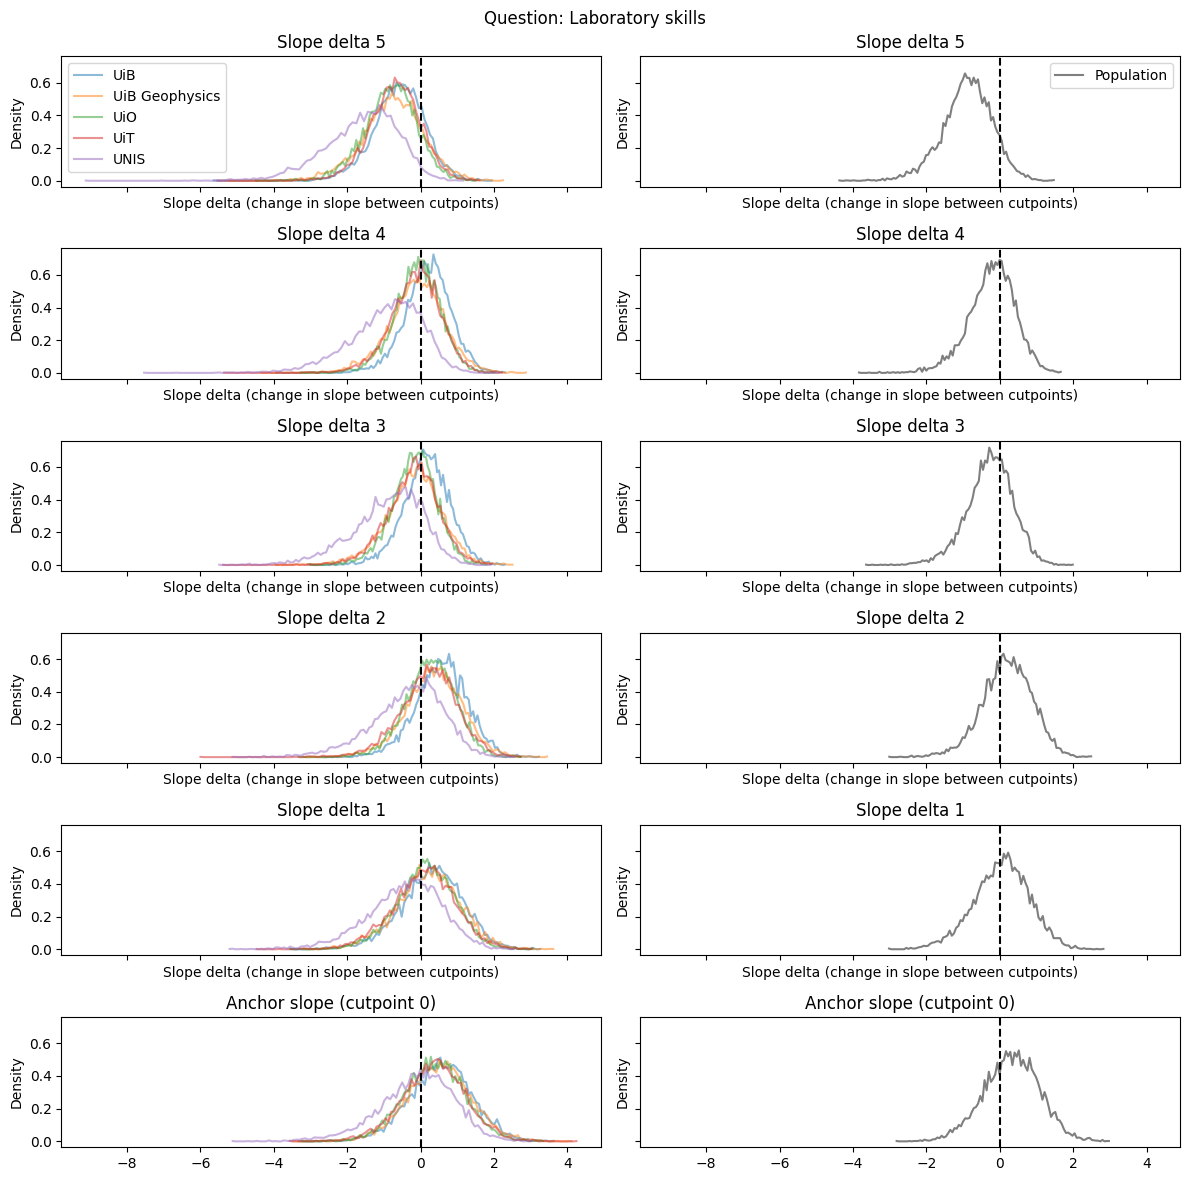

In [ ]:
def plot_slope_deltas(samples_deltas, axs, ax_row, cutpoint_index):
    [samples_delta_population, samples_delta_uib, samples_delta_uibgeophys, samples_delta_uio, samples_delta_uit, samples_delta_unis] = samples_deltas
    # find samples for cutpoint 0 
    samples_delta_population_counts = np.histogram(samples_delta_population[:, cutpoint_index], bins=100, density=True)
    samples_delta_uib_counts = np.histogram(samples_delta_uib[:, cutpoint_index], bins=100, density=True)
    samples_delta_uibgeophys_counts = np.histogram(samples_delta_uibgeophys[:, cutpoint_index], bins=100, density=True)
    samples_delta_uio_counts = np.histogram(samples_delta_uio[:, cutpoint_index], bins=100, density=True)
    samples_delta_uit_counts = np.histogram(samples_delta_uit[:, cutpoint_index], bins=100, density=True)
    samples_delta_unis_counts = np.histogram(samples_delta_unis[:, cutpoint_index], bins=100, density=True)

    # plot the posterior distributions for each slope delta for the population and each group
    axs[ax_row, 1].plot(samples_delta_population_counts[1][:-1], samples_delta_population_counts[0], alpha=0.5, label="Population", color="k")
    axs[ax_row, 0].plot(samples_delta_uib_counts[1][:-1], samples_delta_uib_counts[0], alpha=0.5, label="UiB", color="tab:blue")
    axs[ax_row, 0].plot(samples_delta_uibgeophys_counts[1][:-1], samples_delta_uibgeophys_counts[0], alpha=0.5, label="UiB Geophysics", color="tab:orange")
    axs[ax_row, 0].plot(samples_delta_uio_counts[1][:-1], samples_delta_uio_counts[0], alpha=0.5, label="UiO", color="tab:green")
    axs[ax_row, 0].plot(samples_delta_uit_counts[1][:-1], samples_delta_uit_counts[0], alpha=0.5, label="UiT", color="tab:red")
    axs[ax_row, 0].plot(samples_delta_unis_counts[1][:-1], samples_delta_unis_counts[0], alpha=0.5, label="UNIS", color="tab:purple")
    axs[ax_row, 0].set_title(f"Slope delta {cutpoint_index + 1}")
    axs[ax_row, 1].set_title(f"Slope delta {cutpoint_index + 1}")


def plot_anchor(sample_anchors, axs, ax_row):
    [samples_anchor_population, samples_anchor_groups] = sample_anchors
    # find samples for cutpoint 0 
    samples_anchor_population_counts = np.histogram(samples_anchor_population, bins=100, density=True)
    samples_anchor_uib_counts = np.histogram(samples_anchor_groups[:, 0], bins=100, density=True)
    samples_anchor_uibgeophys_counts = np.histogram(samples_anchor_groups[:, 1], bins=100, density=True)
    samples_anchor_uio_counts = np.histogram(samples_anchor_groups[:, 2], bins=100, density=True)
    samples_anchor_uit_counts = np.histogram(samples_anchor_groups[:, 3], bins=100, density=True)
    samples_anchor_unis_counts = np.histogram(samples_anchor_groups[:, 4], bins=100, density=True)

    # plot the posterior distributions for each slope delta for the population and each group
    axs[ax_row, 1].plot(samples_anchor_population_counts[1][:-1], samples_anchor_population_counts[0], alpha=0.5, label="Population", color="k")
    axs[ax_row, 0].plot(samples_anchor_uib_counts[1][:-1], samples_anchor_uib_counts[0], alpha=0.5, label="UiB", color="tab:blue")
    axs[ax_row, 0].plot(samples_anchor_uibgeophys_counts[1][:-1], samples_anchor_uibgeophys_counts[0], alpha=0.5, label="UiB Geophysics", color="tab:orange")
    axs[ax_row, 0].plot(samples_anchor_uio_counts[1][:-1], samples_anchor_uio_counts[0], alpha=0.5, label="UiO", color="tab:green")
    axs[ax_row, 0].plot(samples_anchor_uit_counts[1][:-1], samples_anchor_uit_counts[0], alpha=0.5, label="UiT", color="tab:red")
    axs[ax_row, 0].plot(samples_anchor_unis_counts[1][:-1], samples_anchor_unis_counts[0], alpha=0.5, label="UNIS", color="tab:purple")
    axs[ax_row, 0].set_title(f"Anchor slope (cutpoint 0)")
    axs[ax_row, 1].set_title(f"Anchor slope (cutpoint 0)")

def plot_slope_deltas_and_anchor(question):
    question_clean = sanitize_key(question)[:50]
    path_slope_deltas_population = f"..\\unconstrained_posteriors\\educators\\{question_clean}_slope_posteriors_population.npy"
    path_slope_anchor_population = f"..\\unconstrained_posteriors\\educators\\{question_clean}_anchor_posteriors_population.npy"
    path_slope_deltas_groups = f"..\\unconstrained_posteriors\\educators\\{question_clean}_slope_posteriors_groups.npy"
    path_slope_anchor_groups = f"..\\unconstrained_posteriors\\educators\\{question_clean}_anchor_posteriors_groups.npy"
    samples_delta_population = np.load(path_slope_deltas_population)
    samples_anchor_population = np.load(path_slope_anchor_population)
    samples_anchor_groups = np.load(path_slope_anchor_groups)
    samples_delta_groups = np.load(path_slope_deltas_groups)
    samples_delta_uib = samples_delta_groups[:, 0, :]
    samples_delta_uibgeophys = samples_delta_groups[:, 1, :]
    samples_delta_uio = samples_delta_groups[:, 2, :]
    samples_delta_uit = samples_delta_groups[:, 3, :]
    samples_delta_unis = samples_delta_groups[:, 4, :]
    
    # calculate the cumulative slope deltas for each group and the population
    samples_delta_population = np.cumsum(samples_delta_population, axis=1)
    samples_delta_uib = np.cumsum(samples_delta_uib, axis=1)
    samples_delta_uibgeophys = np.cumsum(samples_delta_uibgeophys, axis=1)
    samples_delta_uio = np.cumsum(samples_delta_uio, axis=1)
    samples_delta_uit = np.cumsum(samples_delta_uit, axis=1)
    samples_delta_unis = np.cumsum(samples_delta_unis, axis=1)

    # add the anchor slope to the cumulative slope deltas for each group and the population
    samples_delta_population = samples_delta_population + samples_anchor_population[:, None]
    samples_delta_uib = samples_delta_uib + samples_anchor_groups[:, 0][:, None]
    samples_delta_uibgeophys = samples_delta_uibgeophys + samples_anchor_groups[:, 1][:, None]
    samples_delta_uio = samples_delta_uio + samples_anchor_groups[:, 2][:, None]
    samples_delta_uit = samples_delta_uit + samples_anchor_groups[:, 3][:, None]
    samples_delta_unis = samples_delta_unis + samples_anchor_groups[:, 4][:, None]

    samples_deltas = [samples_delta_population, samples_delta_uib, samples_delta_uibgeophys, samples_delta_uio, samples_delta_uit, samples_delta_unis]
    samples_anchors = [samples_anchor_population, samples_anchor_groups]

    num_deltas = samples_delta_population.shape[1]
    fig, axs = plt.subplots(num_deltas + 1, 2, figsize=(12, 12), sharex=True, sharey=True)
    plot_slope_deltas(samples_deltas, axs, num_deltas - 1, 0)
    plot_slope_deltas(samples_deltas, axs, num_deltas - 2, 1)
    plot_slope_deltas(samples_deltas, axs, num_deltas - 3, 2)
    plot_slope_deltas(samples_deltas, axs, num_deltas - 4, 3)
    plot_slope_deltas(samples_deltas, axs, num_deltas - 5, 4)
    plot_anchor(samples_anchors, axs, 5)
    for ax in axs.flatten():
        ax.axvline(0, color="k", linestyle="--")
        ax.set_ylabel("Density")
        if ax not in axs[-1, :]:
            ax.set_xlabel("Slope delta (change in slope between cutpoints)")
    axs[0, 0].legend()
    axs[0, 1].legend()
    fig.suptitle(f"Question: {question}")
    fig.tight_layout()

question = "Laboratory skills"
plot_slope_deltas_and_anchor(question)